# 🛍️ Fake vs Real Luxury Bags Detection
## التجربة 1: البيانات الجدولية فقط (سعر + مواصفات)
**3 موديلات:** MLP | Random Forest | Gradient Boosting  
**التقييم:** Stratified 5-Fold Cross-Validation

In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 1: تحميل المكتبات
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries imported')
print(f'   Device: {device}')

✅ Libraries imported
   Device: cpu


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 2: رفع البيانات
# ════════════════════════════════════════════════════════════

from google.colab import files

print('📂 ارفع ملف products_all_v2.xlsx...')
uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0])

print(f'\n✅ Data loaded: {len(df)} products')
for b in df['brand'].unique():
    print(f'   {b}: {len(df[df["brand"]==b])} (Fake={len(df[(df["brand"]==b) & (df["is_authentic"]==0)])}, Real={len(df[(df["brand"]==b) & (df["is_authentic"]==1)])})')
print(f'   Total:  Fake={len(df[df["is_authentic"]==0])}, Real={len(df[df["is_authentic"]==1])}')

📂 ارفع ملف products_all_v2.xlsx...


Saving products_all_v2.xlsx to products_all_v2.xlsx

✅ Data loaded: 711 products
   Chanel: 188 (Fake=94, Real=94)
   Coach: 189 (Fake=95, Real=94)
   Louis Vuitton: 143 (Fake=48, Real=95)
   YSL: 191 (Fake=96, Real=95)
   Total:  Fake=333, Real=378


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 3: Feature Engineering
# ════════════════════════════════════════════════════════════

categorical_cols = ['Material', 'Closure_Type', 'Style', 'Pattern', 'brand']
label_encoders = {}

print('📌 Encoding categorical features:')
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'   {col}: {len(le.classes_)} categories')

df['name_length'] = df['productName'].str.len()
df['name_word_count'] = df['productName'].str.split().str.len()

feature_cols = ['price_scaled', 'Material_encoded', 'Closure_Type_encoded',
                'Style_encoded', 'Pattern_encoded', 'brand_encoded',
                'name_length', 'name_word_count']

spec_only_cols = ['Material_encoded', 'Closure_Type_encoded', 'Style_encoded',
                  'Pattern_encoded', 'brand_encoded', 'name_length', 'name_word_count']

y = df['is_authentic'].values.astype(np.float32)

print(f'\n✅ Features: {len(feature_cols)} with price, {len(spec_only_cols)} without')

📌 Encoding categorical features:
   Material: 30 categories
   Closure_Type: 16 categories
   Style: 19 categories
   Pattern: 14 categories
   brand: 4 categories

✅ Features: 8 with price, 7 without


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 4: تعريف MLP (أخف — عشان نمنع Overfitting)
# ════════════════════════════════════════════════════════════

class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.LayerNorm(32),
            nn.Dropout(0.4),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze()

print('✅ MLP architecture (lighter version to prevent overfitting):')
print(f'   Input → 64 → 32 → 1')
print(f'   Dropout: 0.4 (increased)')
print(f'   Layers: 2 hidden (reduced from 3)')
temp = TabularMLP(len(feature_cols))
print(f'   Parameters: {sum(p.numel() for p in temp.parameters()):,}')
del temp

✅ MLP architecture (lighter version to prevent overfitting):
   Input → 64 → 32 → 1
   Dropout: 0.4 (increased)
   Layers: 2 hidden (reduced from 3)
   Parameters: 2,881


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 5: دالة تدريب MLP مع Early Stopping
# ════════════════════════════════════════════════════════════

def train_and_evaluate_mlp(X_train, y_train, X_val, y_val, input_dim, epochs=150, patience=15):
    model = TabularMLP(input_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_correct += ((out >= 0.5).float() == yb).sum().item()
            t_total += len(yb)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                v_loss += criterion(out, yb).item()
                v_correct += ((out >= 0.5).float() == yb).sum().item()
                v_total += len(yb)

        avg_tl = t_loss / len(train_loader)
        avg_vl = v_loss / len(val_loader)
        history['train_loss'].append(avg_tl)
        history['val_loss'].append(avg_vl)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

        scheduler.step(avg_vl)

        if avg_vl < best_val_loss:
            best_val_loss = avg_vl
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    preds, probs = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            out = model(Xb.to(device))
            preds.extend((out >= 0.5).float().cpu().numpy())
            probs.extend(out.cpu().numpy())

    return np.array(preds), np.array(probs), history

print('✅ train_and_evaluate_mlp defined')

✅ train_and_evaluate_mlp defined


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 6: Stratified 5-Fold Cross-Validation
# ════════════════════════════════════════════════════════════

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
stratify_col = df['brand'] + '_' + df['is_authentic'].astype(str)

experiments = {
    'With Price': feature_cols,
    'Without Price': spec_only_cols,
}
models_config = {
    'MLP': 'pytorch',
    'Random Forest': 'sklearn',
    'Gradient Boosting': 'sklearn',
}

all_fold_results = []
all_summary = []
all_fold_preds = {}
mlp_histories = {}

print('🚀 Starting 5-Fold Cross-Validation...')
print(f'   {len(experiments)} variants × {len(models_config)} models × {N_FOLDS} folds = {len(experiments)*len(models_config)*N_FOLDS} runs')
print('='*80)

for exp_name, feat_cols in experiments.items():
    df_copy = df.copy()
    if 'price_scaled' in feat_cols:
        scaler = StandardScaler()
        df_copy['price_scaled'] = scaler.fit_transform(df_copy[['price']])

    X_full = df_copy[feat_cols].values.astype(np.float32)

    for model_name, model_type in models_config.items():
        print(f"\n{'─'*60}")
        print(f'📌 {model_name} — {exp_name}')
        print(f"{'─'*60}")

        fold_metrics = []
        all_true, all_pred, all_prob = [], [], []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_full, stratify_col)):
            X_train, X_test = X_full[train_idx], X_full[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            if model_type == 'pytorch':
                val_size = int(0.15 * len(X_train))
                X_tr, X_vl = X_train[:-val_size], X_train[-val_size:]
                y_tr, y_vl = y_train[:-val_size], y_train[-val_size:]
                _, _, history = train_and_evaluate_mlp(X_tr, y_tr, X_vl, y_vl, input_dim=len(feat_cols))
                preds_test, probs_test, hist = train_and_evaluate_mlp(X_train, y_train, X_test, y_test, input_dim=len(feat_cols))
                key = f'{model_name}_{exp_name}'
                if fold == 0:
                    mlp_histories[key] = hist
            else:
                if model_name == 'Random Forest':
                    model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
                else:
                    model = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, min_samples_leaf=5, random_state=42)
                model.fit(X_train, y_train)
                preds_test = model.predict(X_test)
                probs_test = model.predict_proba(X_test)[:, 1]

            acc  = accuracy_score(y_test, preds_test)
            prec = precision_score(y_test, preds_test, zero_division=0)
            rec  = recall_score(y_test, preds_test, zero_division=0)
            f1   = f1_score(y_test, preds_test, zero_division=0)
            auc  = roc_auc_score(y_test, probs_test)

            fold_metrics.append({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc})
            all_true.extend(y_test)
            all_pred.extend(preds_test)
            all_prob.extend(probs_test)

            print(f'   Fold {fold+1}: Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}')
            all_fold_results.append({'Model': model_name, 'Variant': exp_name, 'Fold': fold+1,
                                     'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc})

        result_key = f'{model_name}|{exp_name}'
        all_fold_preds[result_key] = {'true': np.array(all_true), 'pred': np.array(all_pred), 'prob': np.array(all_prob)}

        metrics_df = pd.DataFrame(fold_metrics)
        summary = {
            'Model': model_name, 'Variant': exp_name,
            'Accuracy':  f"{metrics_df['acc'].mean():.4f} ± {metrics_df['acc'].std():.4f}",
            'Precision': f"{metrics_df['prec'].mean():.4f} ± {metrics_df['prec'].std():.4f}",
            'Recall':    f"{metrics_df['rec'].mean():.4f} ± {metrics_df['rec'].std():.4f}",
            'F1-Score':  f"{metrics_df['f1'].mean():.4f} ± {metrics_df['f1'].std():.4f}",
            'AUC-ROC':   f"{metrics_df['auc'].mean():.4f} ± {metrics_df['auc'].std():.4f}",
            'Acc_mean': metrics_df['acc'].mean(),
            'F1_mean':  metrics_df['f1'].mean(),
            'AUC_mean': metrics_df['auc'].mean(),
        }
        all_summary.append(summary)
        print(f"   {'─'*50}")
        print(f"   📊 Mean: Acc={metrics_df['acc'].mean():.4f}±{metrics_df['acc'].std():.4f}  F1={metrics_df['f1'].mean():.4f}±{metrics_df['f1'].std():.4f}  AUC={metrics_df['auc'].mean():.4f}±{metrics_df['auc'].std():.4f}")

print(f"\n{'='*80}")
print(f'✅ All {len(all_fold_results)} runs completed!')

🚀 Starting 5-Fold Cross-Validation...
   2 variants × 3 models × 5 folds = 30 runs

────────────────────────────────────────────────────────────
📌 MLP — With Price
────────────────────────────────────────────────────────────
   Fold 1: Acc=0.944  Prec=0.959  Rec=0.934  F1=0.947  AUC=0.989
   Fold 2: Acc=0.958  Prec=0.961  Rec=0.961  F1=0.961  AUC=0.979
   Fold 3: Acc=0.972  Prec=0.961  Rec=0.987  F1=0.974  AUC=0.991
   Fold 4: Acc=0.958  Prec=0.948  Rec=0.973  F1=0.961  AUC=0.980
   Fold 5: Acc=0.972  Prec=0.974  Rec=0.974  F1=0.974  AUC=0.997
   ──────────────────────────────────────────────────
   📊 Mean: Acc=0.9606±0.0116  F1=0.9630±0.0113  AUC=0.9873±0.0074

────────────────────────────────────────────────────────────
📌 Random Forest — With Price
────────────────────────────────────────────────────────────
   Fold 1: Acc=0.993  Prec=1.000  Rec=0.987  F1=0.993  AUC=1.000
   Fold 2: Acc=0.993  Prec=0.987  Rec=1.000  F1=0.993  AUC=0.998
   Fold 3: Acc=1.000  Prec=1.000  Rec=1.000  F1=

In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 7: جدول النتائج الكامل
# ════════════════════════════════════════════════════════════

summary_df = pd.DataFrame(all_summary)

print('\n' + '='*100)
print('📊 EXPERIMENT 1: COMPLETE RESULTS (5-Fold CV)')
print('='*100)
print(f"\n{'Model':<22} {'Variant':<16} {'Accuracy':<18} {'Precision':<18} {'Recall':<18} {'F1-Score':<18} {'AUC-ROC':<18}")
print('─' * 110)
for _, row in summary_df.iterrows():
    print(f"{row['Model']:<22} {row['Variant']:<16} {row['Accuracy']:<18} {row['Precision']:<18} {row['Recall']:<18} {row['F1-Score']:<18} {row['AUC-ROC']:<18}")

best_idx = summary_df['F1_mean'].idxmax()
best = summary_df.iloc[best_idx]
print(f"\n🏆 Best Model: {best['Model']} ({best['Variant']}) — F1={best['F1-Score']}, AUC={best['AUC-ROC']}")

display(summary_df[['Model', 'Variant', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']])


📊 EXPERIMENT 1: COMPLETE RESULTS (5-Fold CV)

Model                  Variant          Accuracy           Precision          Recall             F1-Score           AUC-ROC           
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
MLP                    With Price       0.9606 ± 0.0116    0.9606 ± 0.0091    0.9657 ± 0.0199    0.9630 ± 0.0113    0.9873 ± 0.0074   
Random Forest          With Price       0.9944 ± 0.0059    0.9948 ± 0.0072    0.9947 ± 0.0072    0.9947 ± 0.0055    0.9996 ± 0.0007   
Gradient Boosting      With Price       0.9930 ± 0.0086    0.9947 ± 0.0073    0.9921 ± 0.0118    0.9934 ± 0.0081    0.9972 ± 0.0063   
MLP                    Without Price    0.9592 ± 0.0103    0.9582 ± 0.0133    0.9657 ± 0.0219    0.9618 ± 0.0100    0.9873 ± 0.0061   
Random Forest          Without Price    0.9733 ± 0.0092    0.9594 ± 0.0182    0.9921 ± 0.0118    0.9753 ± 0.0084    0.9977 ± 0.0010   
Gradient Boosting      Without P

,Model,Variant,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,MLP,With Price,0.9606 ± 0.0116,0.9606 ± 0.0091,0.9657 ± 0.0199,0.9630 ± 0.0113,0.9873 ± 0.0074
1,Random Forest,With Price,0.9944 ± 0.0059,0.9948 ± 0.0072,0.9947 ± 0.0072,0.9947 ± 0.0055,0.9996 ± 0.0007
2,Gradient Boosting,With Price,0.9930 ± 0.0086,0.9947 ± 0.0073,0.9921 ± 0.0118,0.9934 ± 0.0081,0.9972 ± 0.0063
3,MLP,Without Price,0.9592 ± 0.0103,0.9582 ± 0.0133,0.9657 ± 0.0219,0.9618 ± 0.0100,0.9873 ± 0.0061
4,Random Forest,Without Price,0.9733 ± 0.0092,0.9594 ± 0.0182,0.9921 ± 0.0118,0.9753 ± 0.0084,0.9977 ± 0.0010
5,Gradient Boosting,Without Price,0.9775 ± 0.0116,0.9719 ± 0.0240,0.9868 ± 0.0093,0.9791 ± 0.0105,0.9984 ± 0.0011


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 8: Fold-by-Fold Results
# ════════════════════════════════════════════════════════════

fold_df = pd.DataFrame(all_fold_results)

print('\n📊 FOLD-BY-FOLD RESULTS:')
print('='*80)

for exp_name in experiments.keys():
    print(f'\n📌 {exp_name}:')
    print(f"{'Model':<22} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
    print('─' * 80)
    for model_name in models_config.keys():
        mask = (fold_df['Model'] == model_name) & (fold_df['Variant'] == exp_name)
        folds = fold_df[mask]['F1'].values
        print(f"{model_name:<22} {folds[0]:>8.3f} {folds[1]:>8.3f} {folds[2]:>8.3f} {folds[3]:>8.3f} {folds[4]:>8.3f} {folds.mean():>8.3f} {folds.std():>8.3f}")


📊 FOLD-BY-FOLD RESULTS:

📌 With Price:
Model                    Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
────────────────────────────────────────────────────────────────────────────────
MLP                       0.947    0.961    0.974    0.961    0.974    0.963    0.010
Random Forest             0.993    0.993    1.000    1.000    0.987    0.995    0.005
Gradient Boosting         0.993    0.980    1.000    0.993    1.000    0.993    0.007

📌 Without Price:
Model                    Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
────────────────────────────────────────────────────────────────────────────────
MLP                       0.947    0.961    0.974    0.961    0.967    0.962    0.009
Random Forest             0.987    0.967    0.980    0.968    0.974    0.975    0.007
Gradient Boosting         0.993    0.974    0.987    0.968    0.974    0.979    0.009


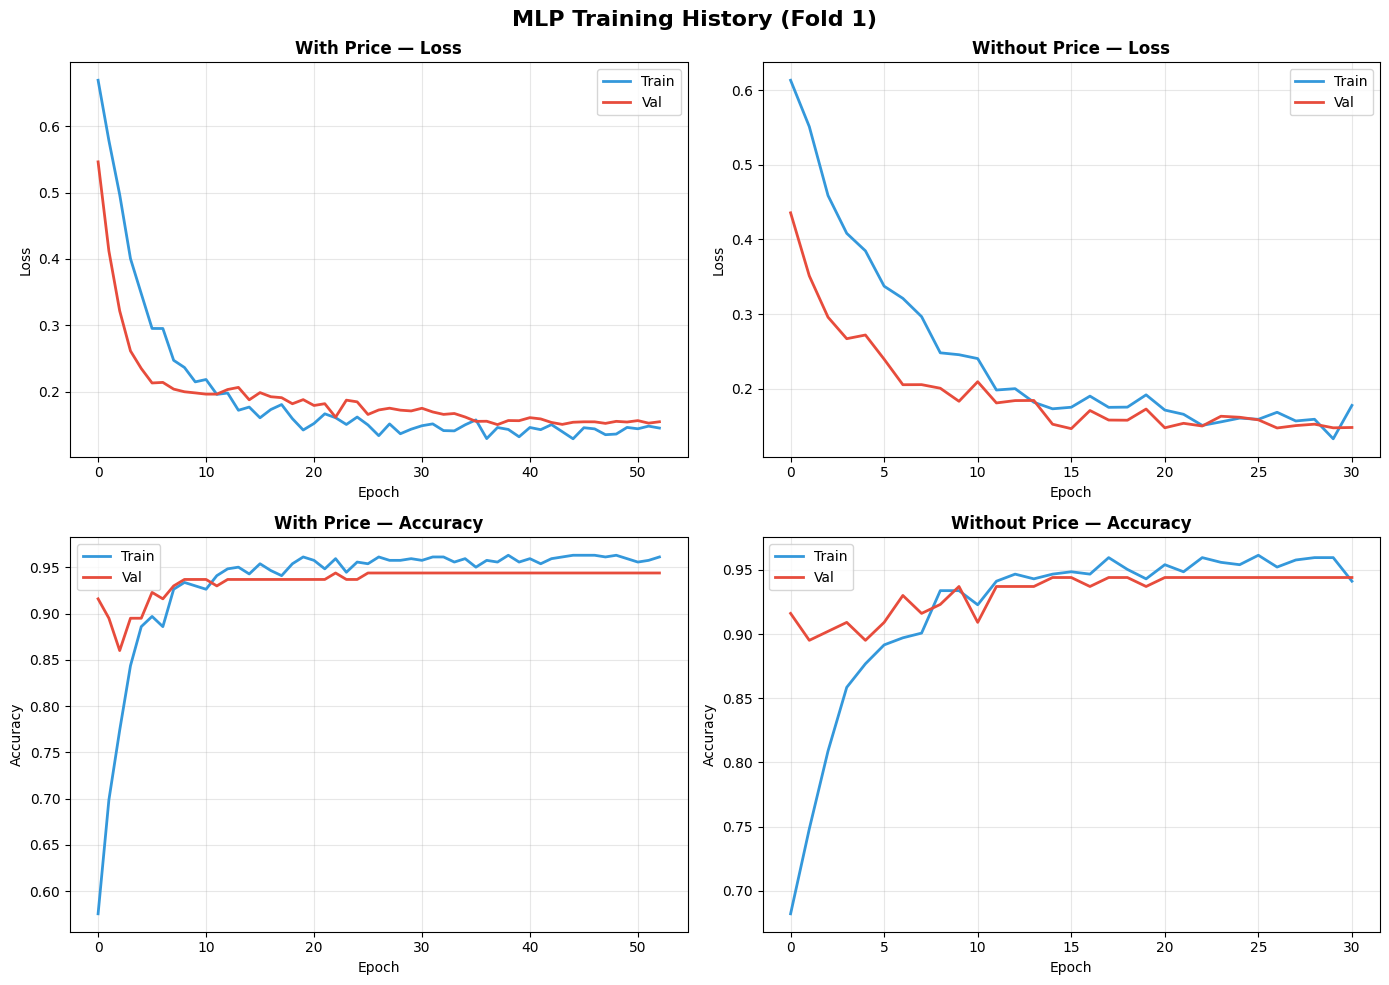

✅ Saved: exp1_mlp_training_history.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 9: MLP Training History (أول Fold)
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLP Training History (Fold 1)', fontsize=16, fontweight='bold')

for i, (key, hist) in enumerate(mlp_histories.items()):
    title = key.replace('MLP_', '')
    axes[0][i].plot(hist['train_loss'], label='Train', color='#3498db', linewidth=2)
    axes[0][i].plot(hist['val_loss'],   label='Val',   color='#e74c3c', linewidth=2)
    axes[0][i].set_title(f'{title} — Loss', fontweight='bold')
    axes[0][i].set_xlabel('Epoch'); axes[0][i].set_ylabel('Loss')
    axes[0][i].legend(); axes[0][i].grid(True, alpha=0.3)

    axes[1][i].plot(hist['train_acc'], label='Train', color='#3498db', linewidth=2)
    axes[1][i].plot(hist['val_acc'],   label='Val',   color='#e74c3c', linewidth=2)
    axes[1][i].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[1][i].set_xlabel('Epoch'); axes[1][i].set_ylabel('Accuracy')
    axes[1][i].legend(); axes[1][i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp1_mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: exp1_mlp_training_history.png')

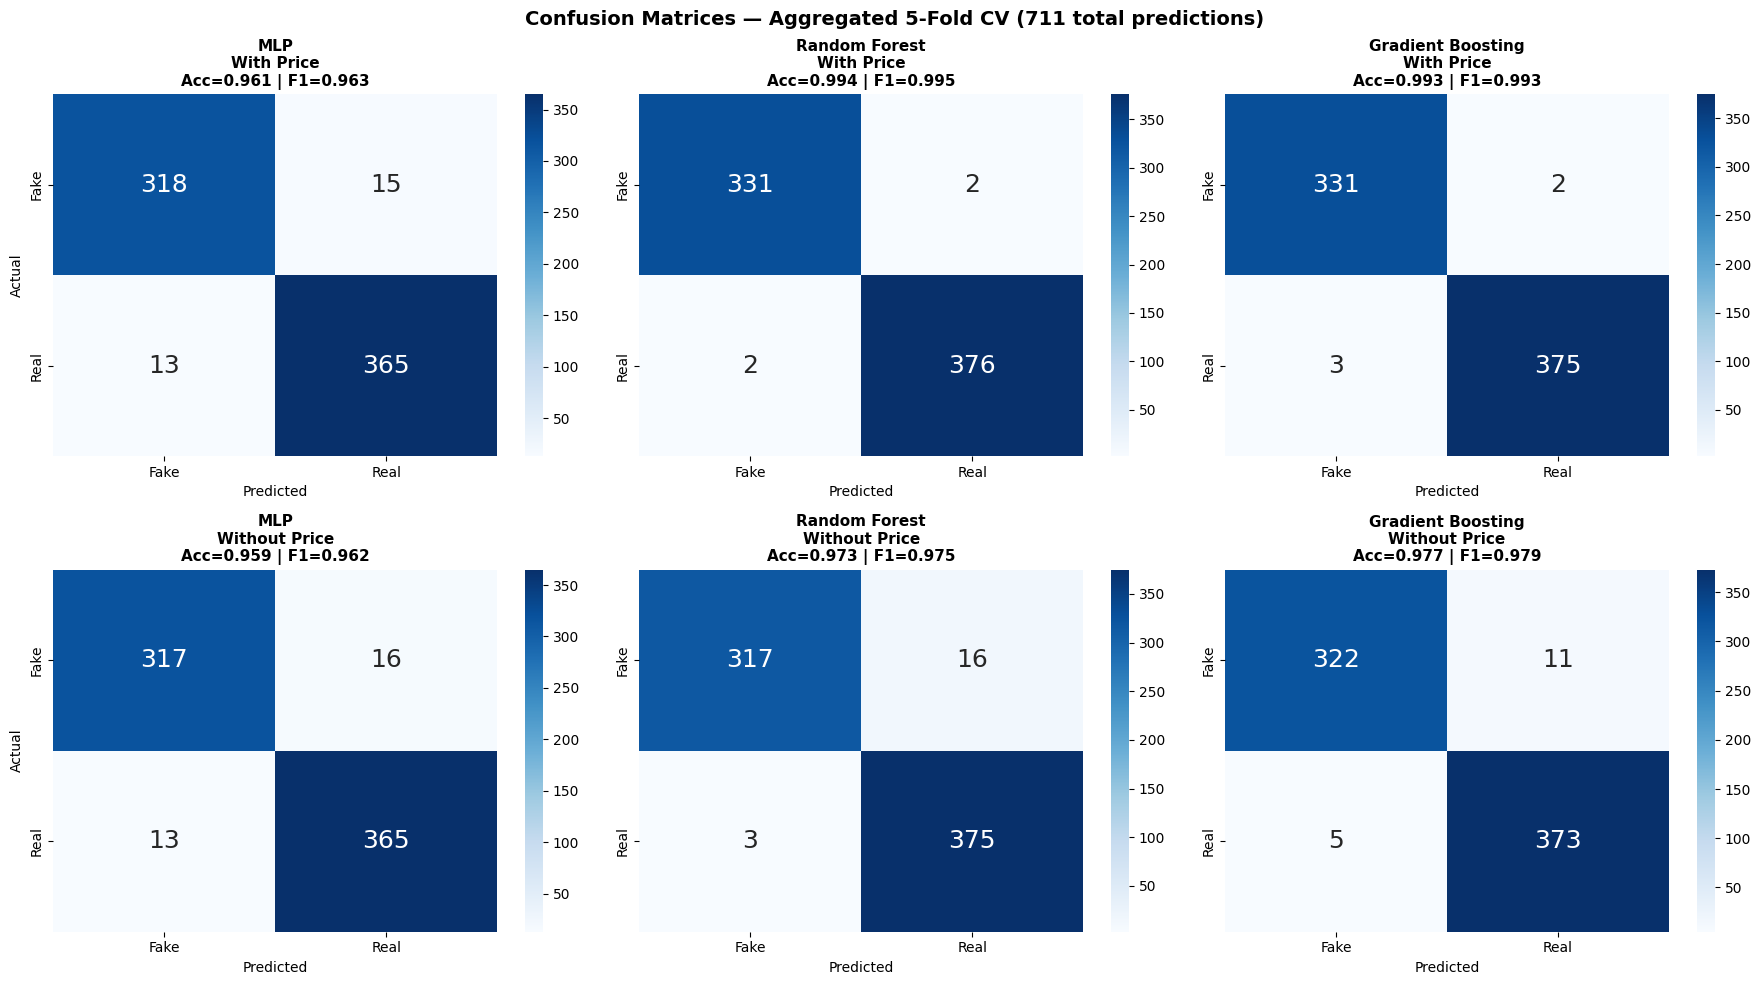

✅ Saved: exp1_confusion_matrices.png

🔍 ERROR ANALYSIS (All Folds Combined):
   MLP                    With Price       Fake→Real: 15 ⚠️  |  Real→Fake: 13  |  Total errors: 28/711
   Random Forest          With Price       Fake→Real:  2 ⚠️  |  Real→Fake:  2  |  Total errors: 4/711
   Gradient Boosting      With Price       Fake→Real:  2 ⚠️  |  Real→Fake:  3  |  Total errors: 5/711
   MLP                    Without Price    Fake→Real: 16 ⚠️  |  Real→Fake: 13  |  Total errors: 29/711
   Random Forest          Without Price    Fake→Real: 16 ⚠️  |  Real→Fake:  3  |  Total errors: 19/711
   Gradient Boosting      Without Price    Fake→Real: 11 ⚠️  |  Real→Fake:  5  |  Total errors: 16/711


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 10: Confusion Matrices
# ════════════════════════════════════════════════════════════

total_preds = len(df)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Confusion Matrices — Aggregated 5-Fold CV ({total_preds} total predictions)', fontsize=14, fontweight='bold')

for i, (key, data) in enumerate(all_fold_preds.items()):
    model_name, variant = key.split('|')
    row = 0 if variant == 'With Price' else 1
    col = list(models_config.keys()).index(model_name)
    ax = axes[row][col]

    cm  = confusion_matrix(data['true'], data['pred'])
    acc = accuracy_score(data['true'], data['pred'])
    f1  = f1_score(data['true'], data['pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, annot_kws={'size': 18},
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    ax.set_title(f'{model_name}\n{variant}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual' if col == 0 else '')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('exp1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: exp1_confusion_matrices.png')

print('\n🔍 ERROR ANALYSIS (All Folds Combined):')
print('='*70)
for key, data in all_fold_preds.items():
    model_name, variant = key.split('|')
    cm = confusion_matrix(data['true'], data['pred'])
    fake_as_real = cm[0][1]
    real_as_fake = cm[1][0]
    total = len(data['true'])
    print(f'   {model_name:<22} {variant:<16} Fake→Real: {fake_as_real:>2} ⚠️  |  Real→Fake: {real_as_fake:>2}  |  Total errors: {fake_as_real+real_as_fake}/{total}')

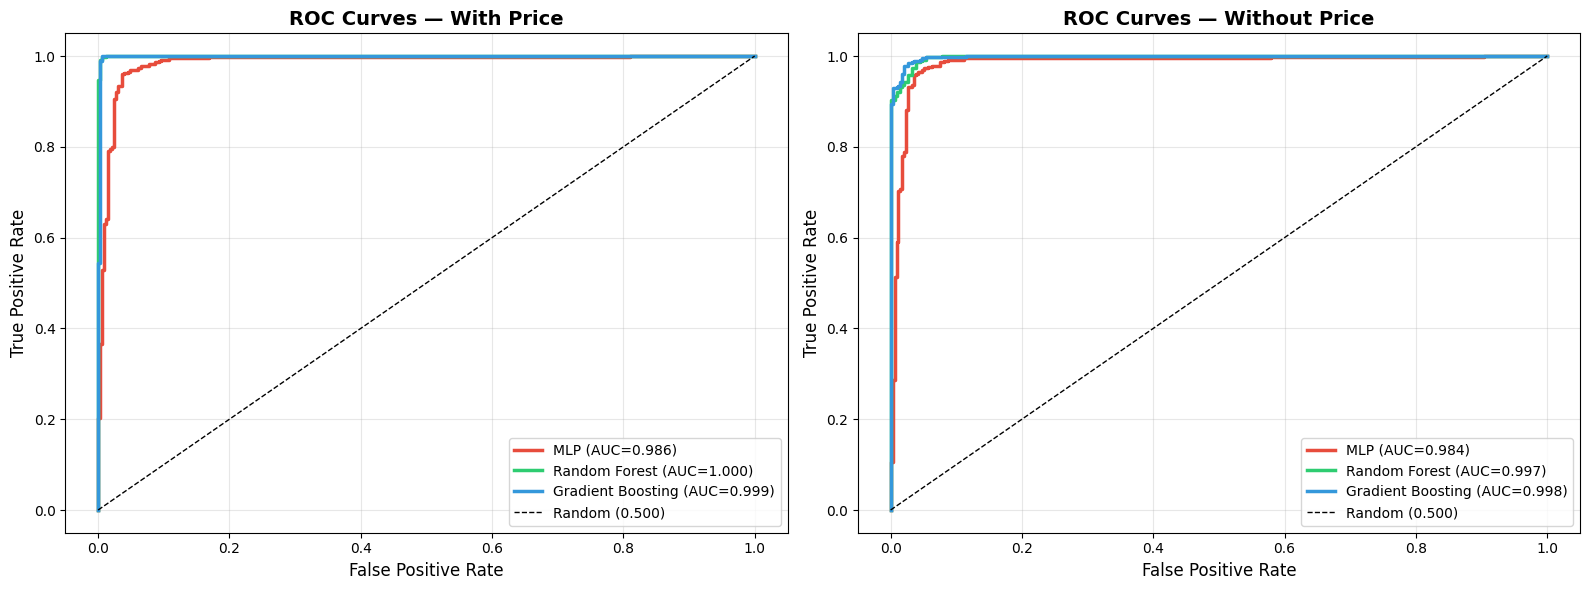

✅ Saved: exp1_roc_curves.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 11: ROC Curves
# ════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = {'MLP': '#e74c3c', 'Random Forest': '#2ecc71', 'Gradient Boosting': '#3498db'}

for ax, variant in [(ax1, 'With Price'), (ax2, 'Without Price')]:
    for model_name in models_config.keys():
        key  = f'{model_name}|{variant}'
        data = all_fold_preds[key]
        fpr, tpr, _ = roc_curve(data['true'], data['prob'])
        auc = roc_auc_score(data['true'], data['prob'])
        ax.plot(fpr, tpr, color=colors[model_name], linewidth=2.5, label=f'{model_name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curves — {variant}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp1_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: exp1_roc_curves.png')

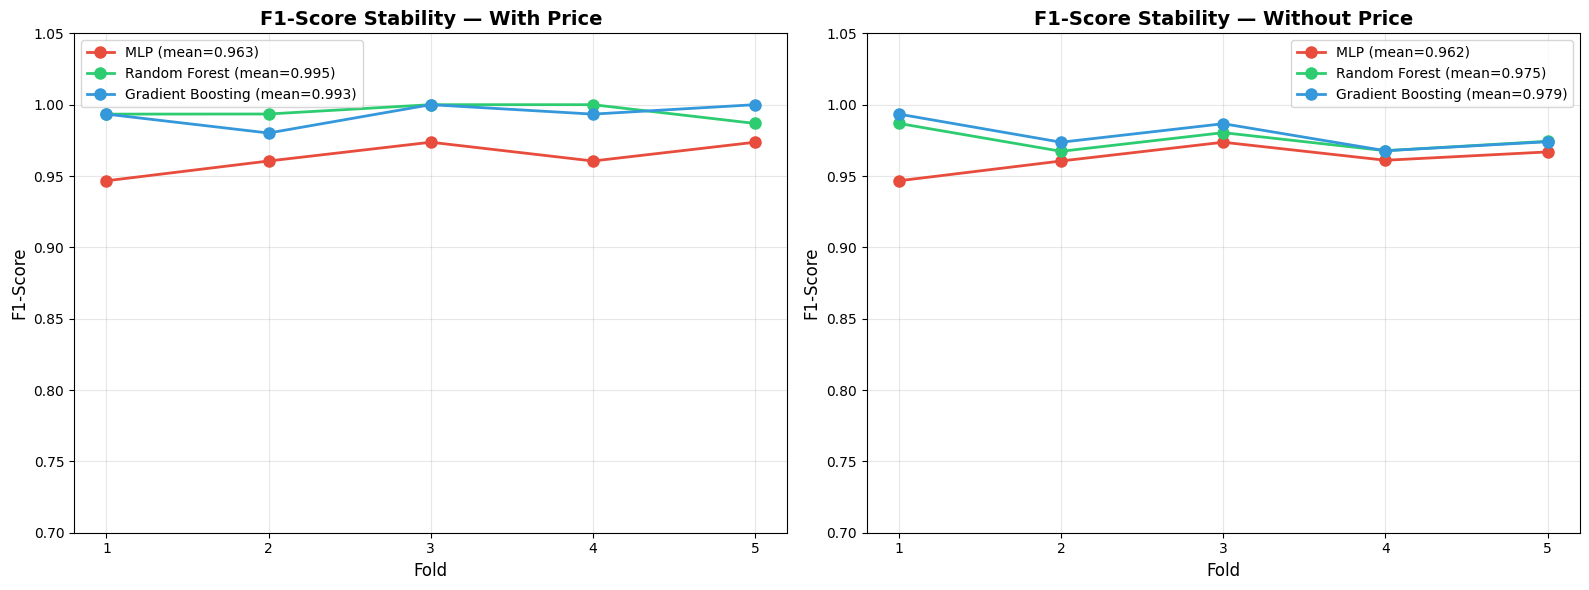

✅ Saved: exp1_fold_stability.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 14: Fold Stability Chart
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_model = {'MLP': '#e74c3c', 'Random Forest': '#2ecc71', 'Gradient Boosting': '#3498db'}

for ax, variant in [(axes[0], 'With Price'), (axes[1], 'Without Price')]:
    for model_name in models_config.keys():
        mask = (fold_df['Model'] == model_name) & (fold_df['Variant'] == variant)
        folds_f1 = fold_df[mask]['F1'].values
        ax.plot(range(1, 6), folds_f1, 'o-', color=colors_model[model_name],
                linewidth=2, markersize=8, label=f"{model_name} (mean={folds_f1.mean():.3f})")
    ax.set_xlabel('Fold', fontsize=12); ax.set_ylabel('F1-Score', fontsize=12)
    ax.set_title(f'F1-Score Stability — {variant}', fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 6)); ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3); ax.set_ylim(0.7, 1.05)

plt.tight_layout()
plt.savefig('exp1_fold_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: exp1_fold_stability.png')

In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 15: Brand Analysis
# ════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

print(f"\n{'='*60}")
print(f"📊 Brand Analysis — Best Model: {best['Model']} ({best['Variant']})")
print(f"{'='*60}")

best_feat_cols = feature_cols if best['Variant'] == 'With Price' else spec_only_cols

if best['Variant'] == 'With Price':
    scaler_brand = StandardScaler()
    df['price_scaled'] = scaler_brand.fit_transform(df[['price']])

X_wp = df[best_feat_cols].values.astype(np.float32)
stratify_col_arr = (df['brand'] + '_' + df['is_authentic'].astype(str)).values

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_wp, y, df.index, test_size=0.2, random_state=42, stratify=stratify_col_arr
)

if best['Model'] == 'Random Forest':
    brand_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42)
elif best['Model'] == 'Gradient Boosting':
    brand_model = GradientBoostingClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
else:
    brand_model = GradientBoostingClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)

brand_model.fit(X_tr, y_tr)
brand_preds = brand_model.predict(X_te)

test_df = df.loc[idx_te].copy()
test_df['predicted'] = brand_preds

# حلقة ديناميكية على كل البراندات
for brand in df['brand'].unique():
    brand_df = test_df[test_df['brand'] == brand]
    if len(brand_df) == 0:
        continue
    b_acc  = accuracy_score(brand_df['is_authentic'], brand_df['predicted'])
    b_prec = precision_score(brand_df['is_authentic'], brand_df['predicted'], zero_division=0)
    b_rec  = recall_score(brand_df['is_authentic'], brand_df['predicted'], zero_division=0)
    b_f1   = f1_score(brand_df['is_authentic'], brand_df['predicted'], zero_division=0)
    b_cm   = confusion_matrix(brand_df['is_authentic'], brand_df['predicted'])

    print(f"\n   📍 {brand} ({len(brand_df)} products in test):")
    print(f"      Accuracy:  {b_acc:.3f}")
    print(f"      Precision: {b_prec:.3f}")
    print(f"      Recall:    {b_rec:.3f}")
    print(f"      F1-Score:  {b_f1:.3f}")
    print(f"      Fake→Fake: {b_cm[0][0]}  |  Fake→Real: {b_cm[0][1]} ⚠️")
    print(f"      Real→Fake: {b_cm[1][0]}  |  Real→Real: {b_cm[1][1]}")


📊 Brand Analysis — Best Model: Random Forest (With Price)

   📍 Chanel (38 products in test):
      Accuracy:  0.974
      Precision: 0.950
      Recall:    1.000
      F1-Score:  0.974
      Fake→Fake: 18  |  Fake→Real: 1 ⚠️
      Real→Fake: 0  |  Real→Real: 19

   📍 Coach (38 products in test):
      Accuracy:  1.000
      Precision: 1.000
      Recall:    1.000
      F1-Score:  1.000
      Fake→Fake: 19  |  Fake→Real: 0 ⚠️
      Real→Fake: 0  |  Real→Real: 19

   📍 Louis Vuitton (29 products in test):
      Accuracy:  1.000
      Precision: 1.000
      Recall:    1.000
      F1-Score:  1.000
      Fake→Fake: 10  |  Fake→Real: 0 ⚠️
      Real→Fake: 0  |  Real→Real: 19

   📍 YSL (38 products in test):
      Accuracy:  1.000
      Precision: 1.000
      Recall:    1.000
      F1-Score:  1.000
      Fake→Fake: 19  |  Fake→Real: 0 ⚠️
      Real→Fake: 0  |  Real→Real: 19


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 16: Classification Reports
# ════════════════════════════════════════════════════════════

print('\n📋 CLASSIFICATION REPORTS (Aggregated All Folds)')
print('='*70)

for key, data in all_fold_preds.items():
    model_name, variant = key.split('|')
    print(f"\n{'─'*60}")
    print(f'📌 {model_name} — {variant}')
    print(f"{'─'*60}")
    print(classification_report(data['true'], data['pred'], target_names=['Fake (0)', 'Real (1)']))


📋 CLASSIFICATION REPORTS (Aggregated All Folds)

────────────────────────────────────────────────────────────
📌 MLP — With Price
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Fake (0)       0.96      0.95      0.96       333
    Real (1)       0.96      0.97      0.96       378

    accuracy                           0.96       711
   macro avg       0.96      0.96      0.96       711
weighted avg       0.96      0.96      0.96       711


────────────────────────────────────────────────────────────
📌 Random Forest — With Price
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99       333
    Real (1)       0.99      0.99      0.99       378

    accuracy                           0.99       711
   macro avg       0.99      0.99      0.99       711
weighted avg       0.99      0.99      0.99       711


──

In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 17: حفظ كل شي
# ════════════════════════════════════════════════════════════

import joblib

summary_df[['Model', 'Variant', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].to_csv('exp1_results_summary.csv', index=False)
fold_df.to_csv('exp1_results_per_fold.csv', index=False)
summary_df[['Model', 'Variant', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].to_excel('exp1_results_summary.xlsx', index=False)
joblib.dump(rf_full, 'exp1_rf_with_price.joblib')
joblib.dump(gb_full, 'exp1_gb_with_price.joblib')

print('\n✅ ALL FILES SAVED:')
print('   📊 exp1_results_summary.csv / .xlsx')
print('   📊 exp1_results_per_fold.csv')
print('   🌳 exp1_rf_with_price.joblib')
print('   🚀 exp1_gb_with_price.joblib')
print('   🖼️ exp1_mlp_training_history.png')
print('   🖼️ exp1_confusion_matrices.png')
print('   🖼️ exp1_roc_curves.png')
print('   🖼️ exp1_feature_importance.png')
print('   🖼️ exp1_model_comparison.png')
print('   🖼️ exp1_fold_stability.png')
print('\n' + '='*60)
print('🎉 EXPERIMENT 1 COMPLETE! (5-Fold CV)')
print('='*60)
print(f"\n🏆 Best: {best['Model']} ({best['Variant']})")
print(f"   F1:  {best['F1-Score']}")
print(f"   AUC: {best['AUC-ROC']}")
print(f'\n➡️ Next: Experiment 2 — Images Only (EfficientNet-B0)')


✅ ALL FILES SAVED:
   📊 exp1_results_summary.csv / .xlsx
   📊 exp1_results_per_fold.csv
   🌳 exp1_rf_with_price.joblib
   🚀 exp1_gb_with_price.joblib
   🖼️ exp1_mlp_training_history.png
   🖼️ exp1_confusion_matrices.png
   🖼️ exp1_roc_curves.png
   🖼️ exp1_feature_importance.png
   🖼️ exp1_model_comparison.png
   🖼️ exp1_fold_stability.png

🎉 EXPERIMENT 1 COMPLETE! (5-Fold CV)

🏆 Best: Random Forest (With Price)
   F1:  0.9947 ± 0.0055
   AUC: 0.9996 ± 0.0007

➡️ Next: Experiment 2 — Images Only (EfficientNet-B0)
